In [34]:
import matplotlib.pyplot as plt
import time
import json
import seaborn as sns
from src.utility_functions import *
from src.variable import *
from src.test import predict_and_transform_new
from src.scaler import standard_scaling_transform
%load_ext autoreload
%autoreload 2

In [35]:
target_scaling_method = 'standard'
data_dir = "./graph_data/test_case_7"
target_file_weight_filepath = None
experiment_name = "test_case_7"

target_weight = None
verbose = True
device = 'cuda' if torch.cuda.is_available() else 'cpu'
target = "y"
fold_name = ""
label_mask = []

In [36]:
data_dir = os.path.join('graph_data', experiment_name, fold_name)
output_dir = os.path.join('output', experiment_name, fold_name)
config_dir = os.path.join('config', experiment_name)

### Step 1: Load Data
train_data_filepath = os.path.join(data_dir, TRAIN_SET)
valid_data_filepath = os.path.join(data_dir, VALID_SET)
test_data_filepath = os.path.join(data_dir, TEST_SET)
msg(f"Loading train data from {train_data_filepath}", verbose=verbose)
with open(train_data_filepath, 'rb') as f:
    train_data = pickle.load(f)
msg(f"Loading valid data from {valid_data_filepath}", verbose=verbose)
with open(valid_data_filepath, 'rb') as f:
    valid_data = pickle.load(f)
with open(test_data_filepath, 'rb') as f:
    test_data = pickle.load(f)
target_dim, train_data = compute_target_dim_and_transform_train_data(train_data, label_mask, verbose)

input_scaler_filepath = os.path.join(output_dir, INPUT_SCALER)
with open(input_scaler_filepath, 'rb') as f:
    input_scaler = pickle.load(f)
target_scaler_filepath = os.path.join(output_dir, TARGET_SCALER)
with open(target_scaler_filepath, 'rb') as f:
    target_scaler = pickle.load(f)
train_data = standard_scaling_transform(train_data, INPUT, input_scaler)
train_data = standard_scaling_transform(train_data, TARGET, target_scaler)
valid_data = standard_scaling_transform(valid_data, INPUT, input_scaler)
valid_data = standard_scaling_transform(valid_data, TARGET, target_scaler)
test_data = standard_scaling_transform(test_data, INPUT, input_scaler)
test_data = standard_scaling_transform(test_data, TARGET, target_scaler)

Loading train data from graph_data\test_case_7\train.pkl
Loading valid data from graph_data\test_case_7\val.pkl
No label mask provided, using default mask with all y elements, target dimension is set to 21


In [37]:
data = train_data + valid_data + test_data

In [38]:
output_dir = os.path.join('output', experiment_name)
config_dir = os.path.join('config', experiment_name)
config_files = natural_sort([f for f in os.listdir(config_dir) if f.endswith('.json')])
max_len = len(str(len(config_files)))

for i, config_file in enumerate(config_files):
    if i != 11:
        continue
    start_time = time.time()
    config_filepath = os.path.join(config_dir, config_file)
    with open(config_filepath, 'r') as f:
        params = json.load(f)
    batch_size = params['batch_size']
    model_filepath = os.path.join(output_dir, 'models', f'config_{config_file}_checkpoint.pth')
    model = torch.load(model_filepath)

    break

C:\Users\Tansu\AppData\Local\Temp\ipykernel_47088\898785602.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_filepath)


In [39]:
train_preds, train_trues = predict_and_transform_new(model=model, 
                                                data=train_data, 
                                                batch_size=batch_size, 
                                                device=device, 
                                                target_scaler=target_scaler,
                                                target_scaling_method=target_scaling_method)
valid_preds, valid_trues = predict_and_transform_new(model=model, 
                                                 data=valid_data, 
                                                 batch_size=len(valid_data), 
                                                 device=device, 
                                                 target_scaler=target_scaler,
                                                 target_scaling_method=target_scaling_method)
meanARE, maxARE = mean_maxARE_by_axis(valid_preds, valid_trues)
meanARE_range, maxARE_range = mean_maxARE_by_range(valid_preds, valid_trues)

In [40]:
y_true = valid_trues
y_pred = valid_preds
axis = 0
min_val = np.min(y_true, axis=axis, keepdims=True)
range_val = np.ptp(y_true, axis=axis)
range_val = np.where(range_val == 0, 1, range_val)  # Avoid division by zero
meanARE = np.around(100*np.mean(np.abs((y_pred-y_true)/(range_val + min_val)), axis=axis), decimals=2)
maxARE = np.around(100*np.max(np.abs((y_pred-y_true)/(range_val + min_val)), axis=axis), decimals=2)

In [41]:
num_rows = 6
row_index = np.zeros(21)
col_index = np.zeros(21)

row_start = 1
row_length = num_rows

for y in range(21):
    while y + 1 > row_start + row_length - 1:
        row_start += row_length
        row_length -= 1

    row_index[y] = int(num_rows - row_length + 1)
    col_index[y] = int(y + 1 - row_start + row_index[y])

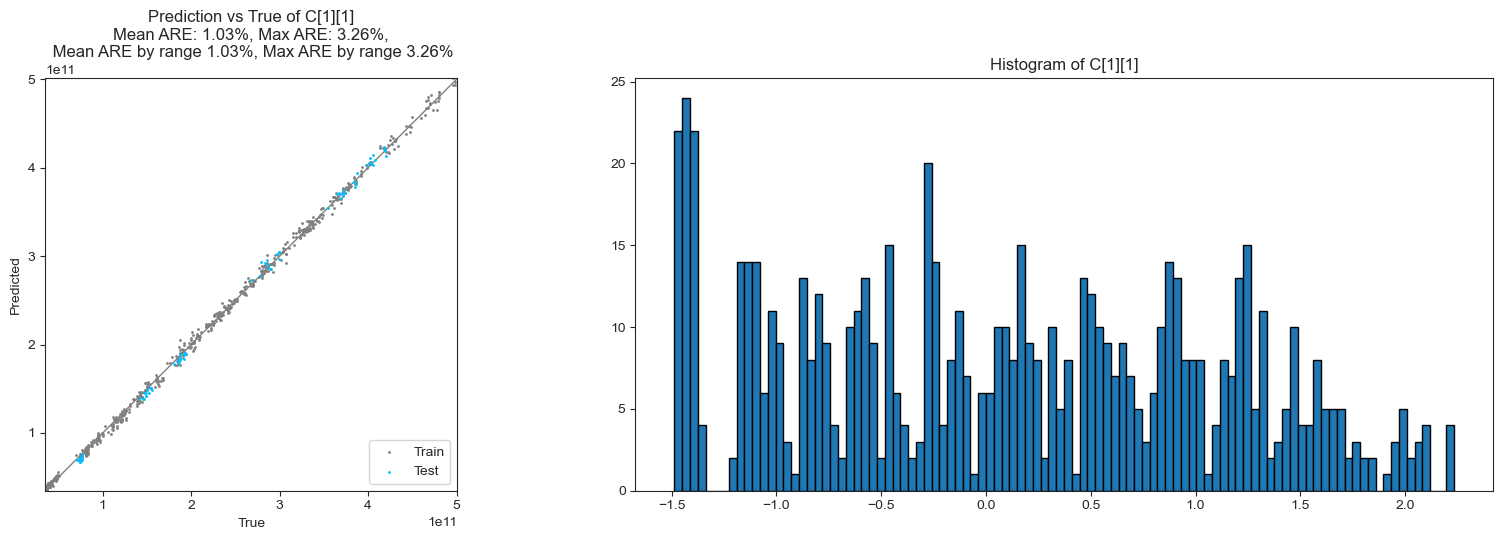

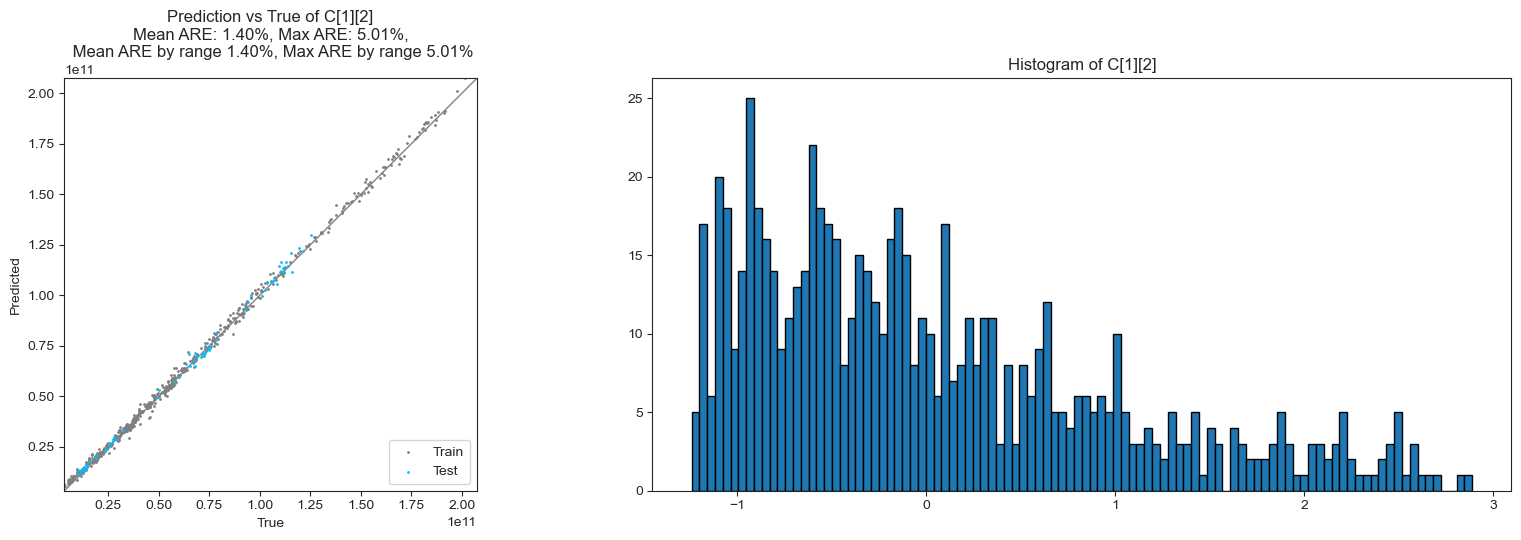

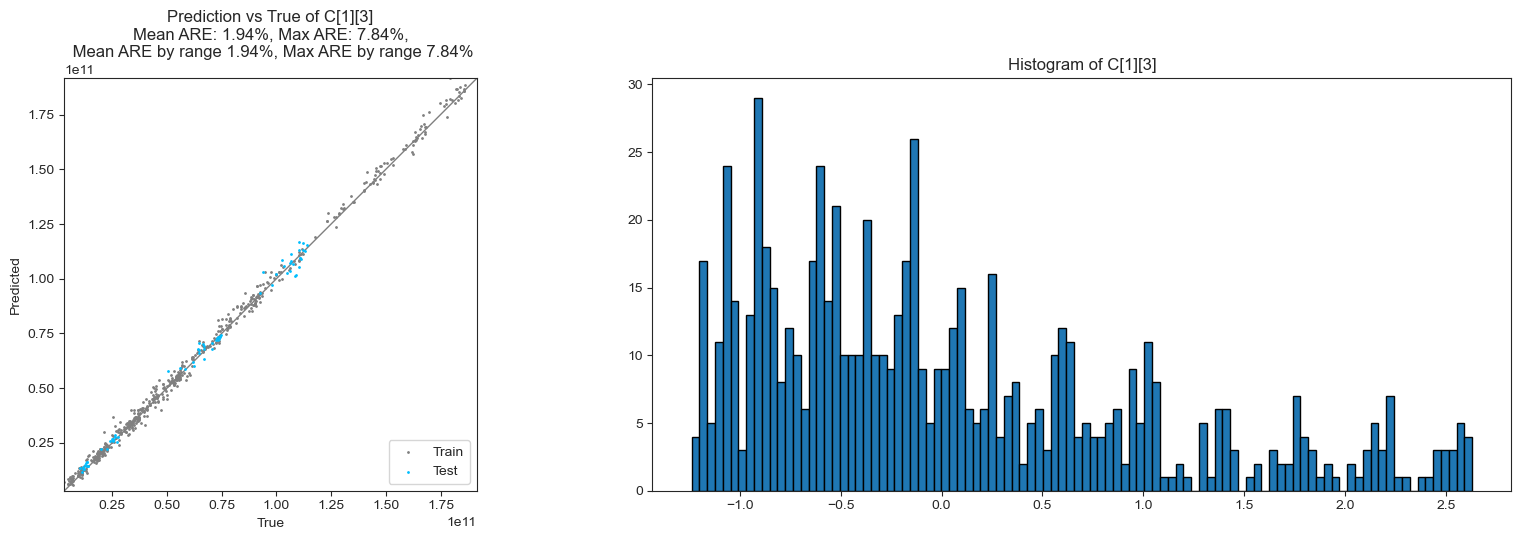

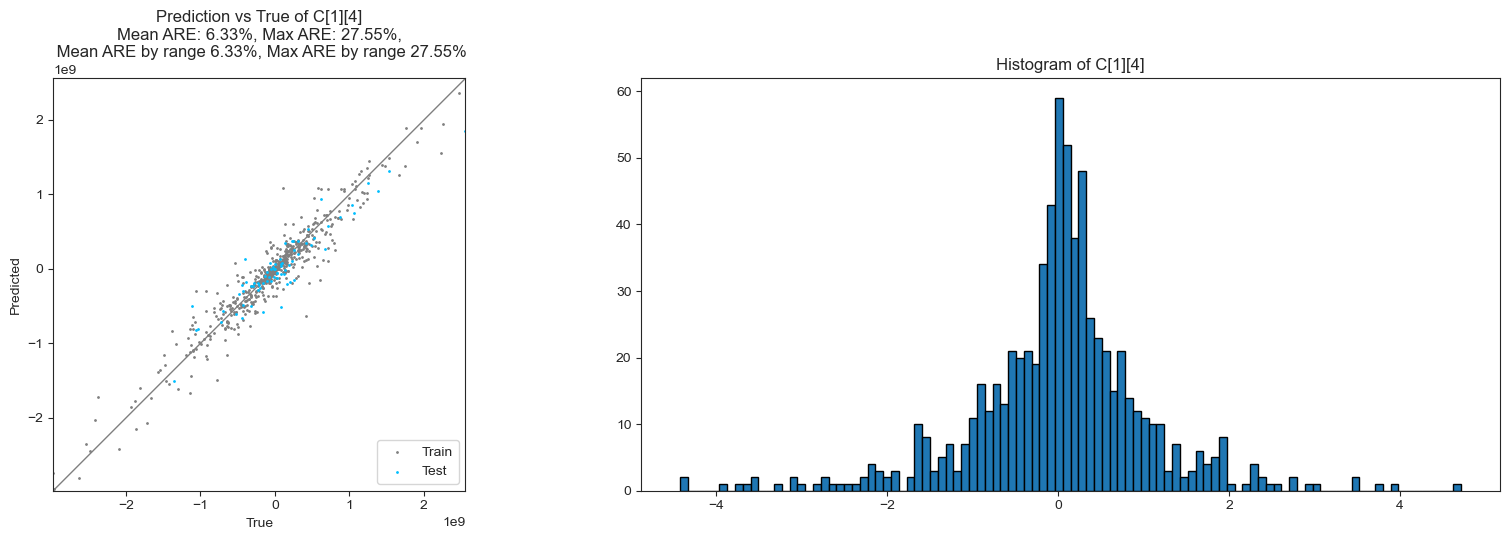

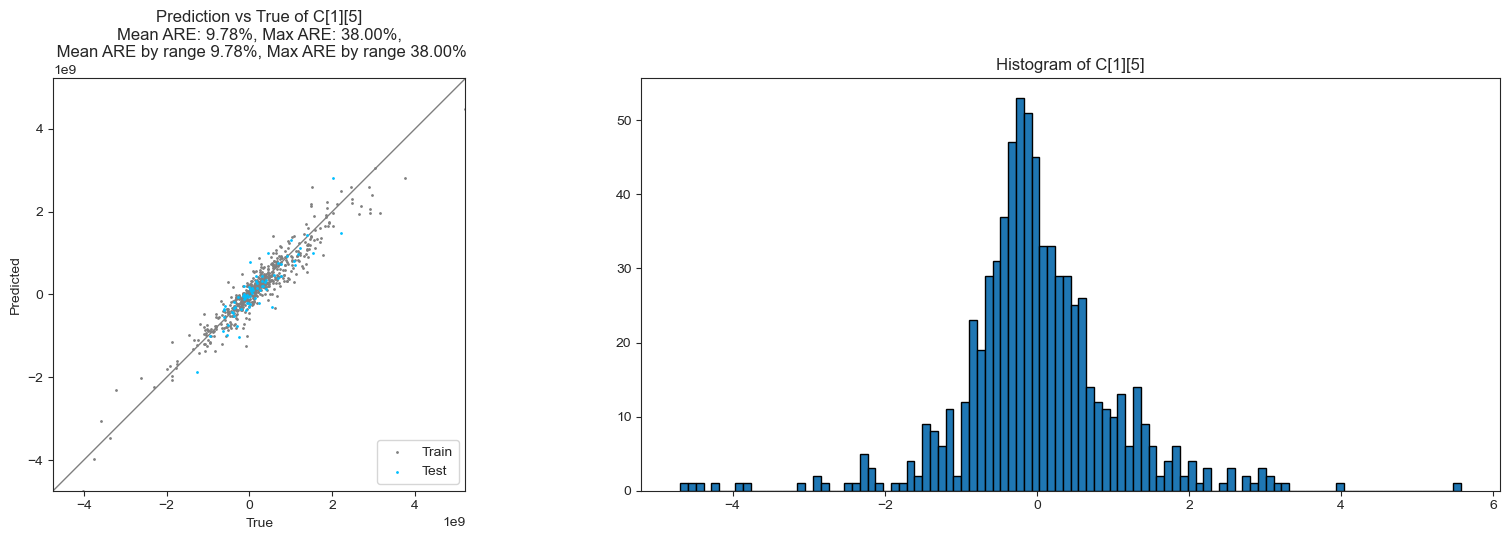

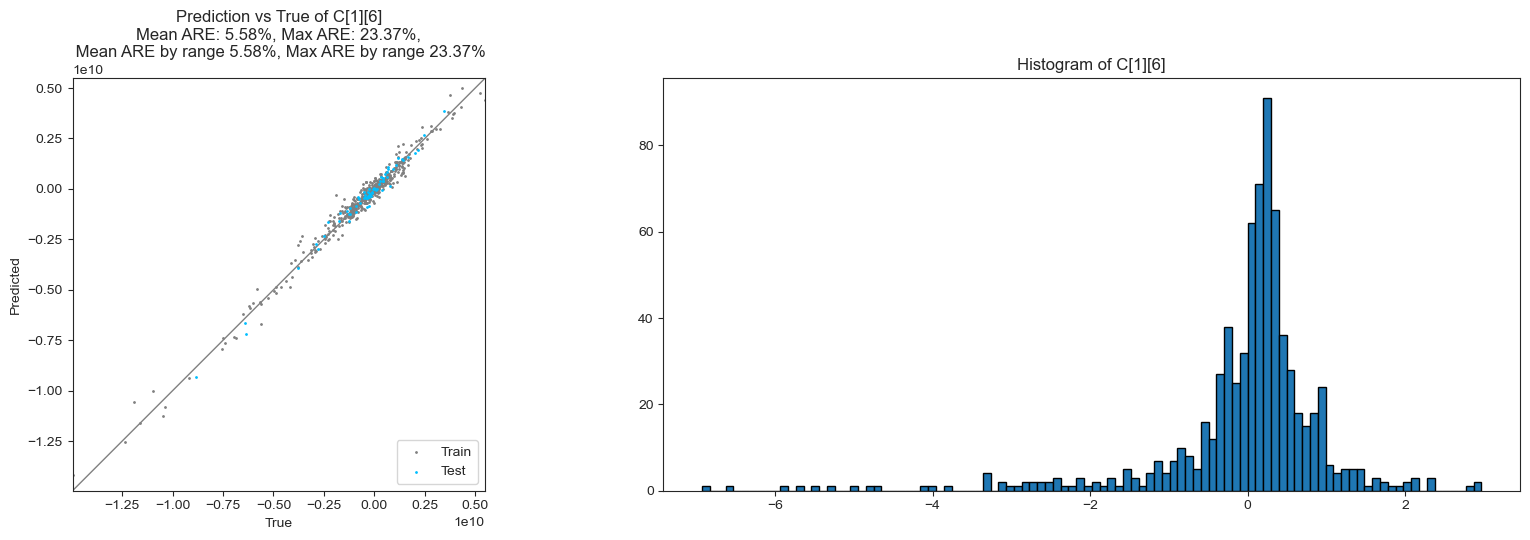

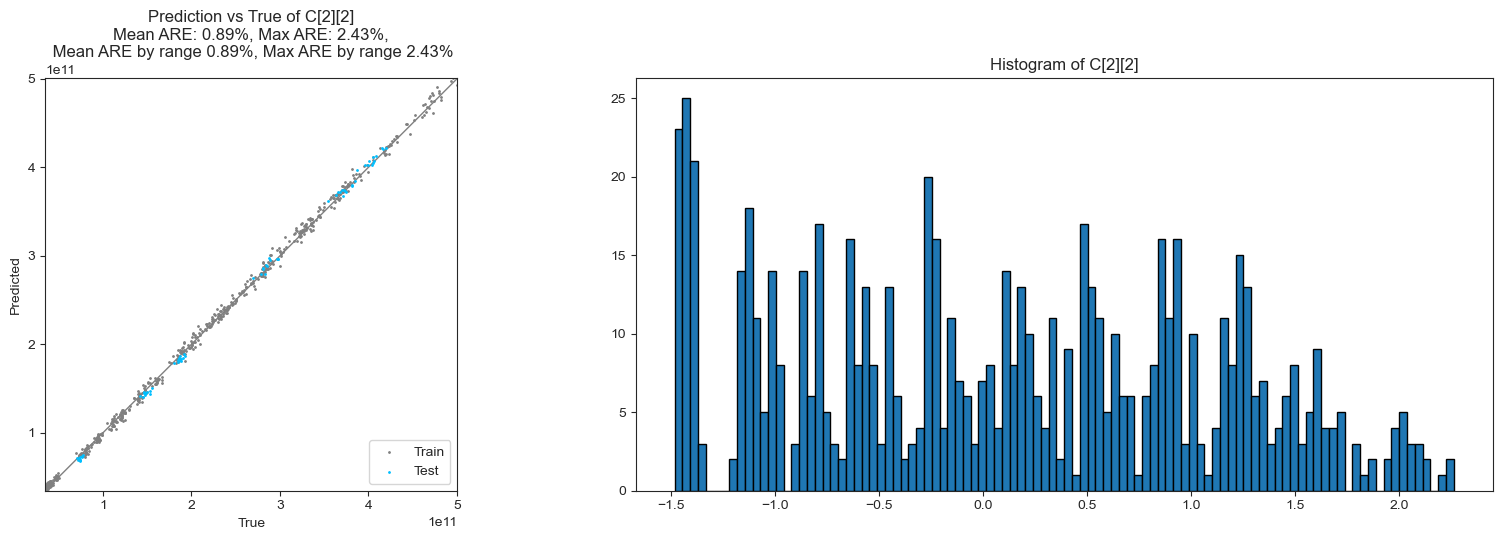

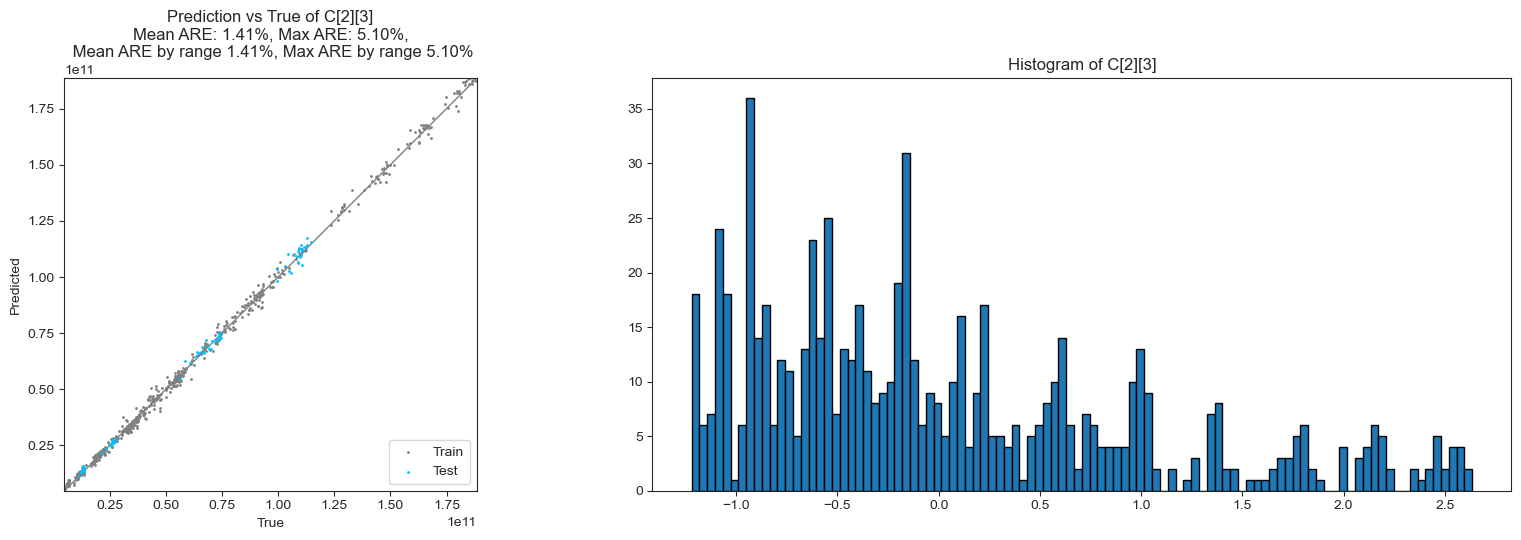

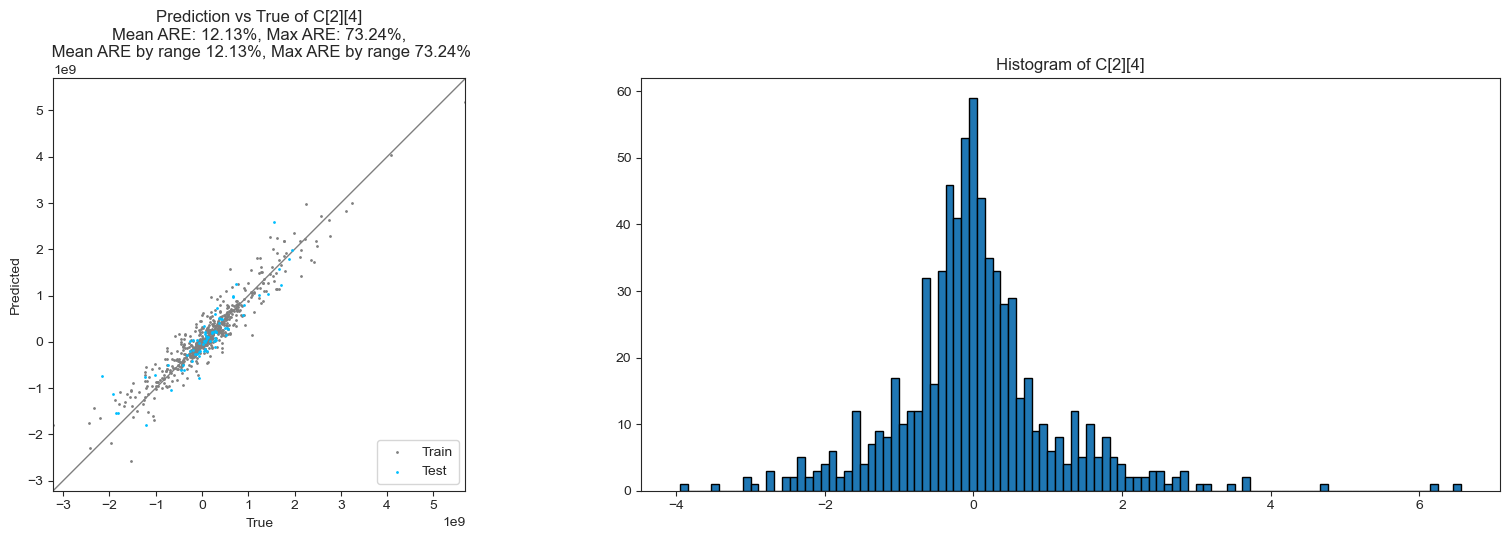

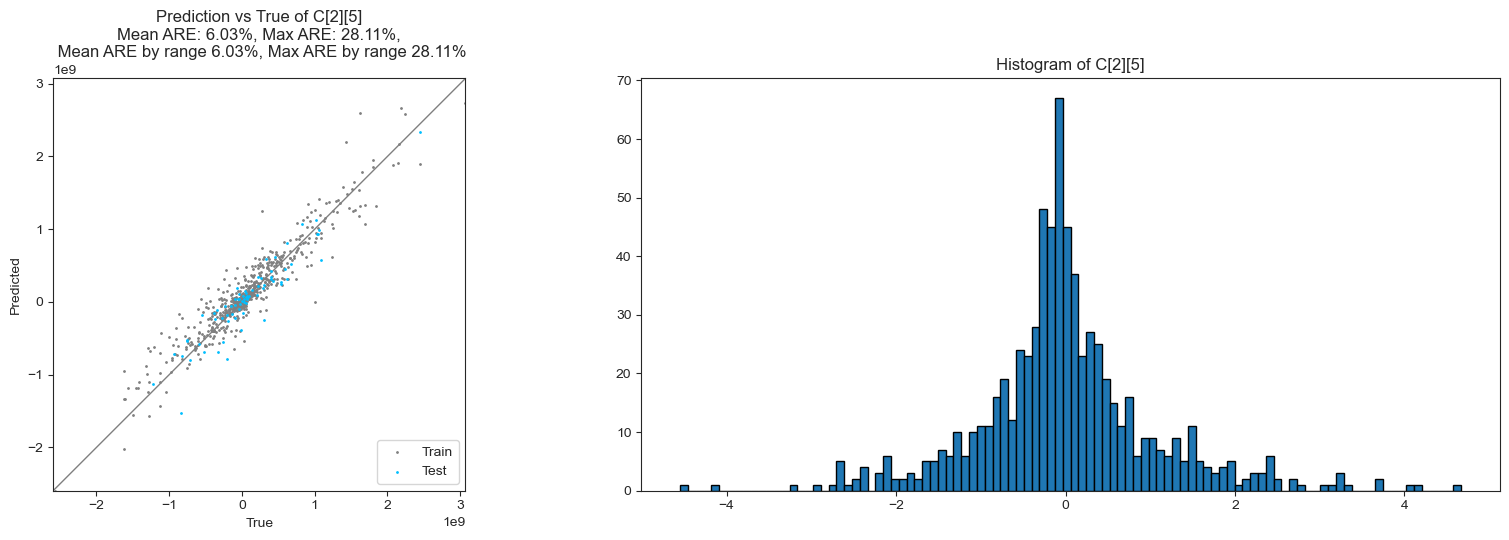

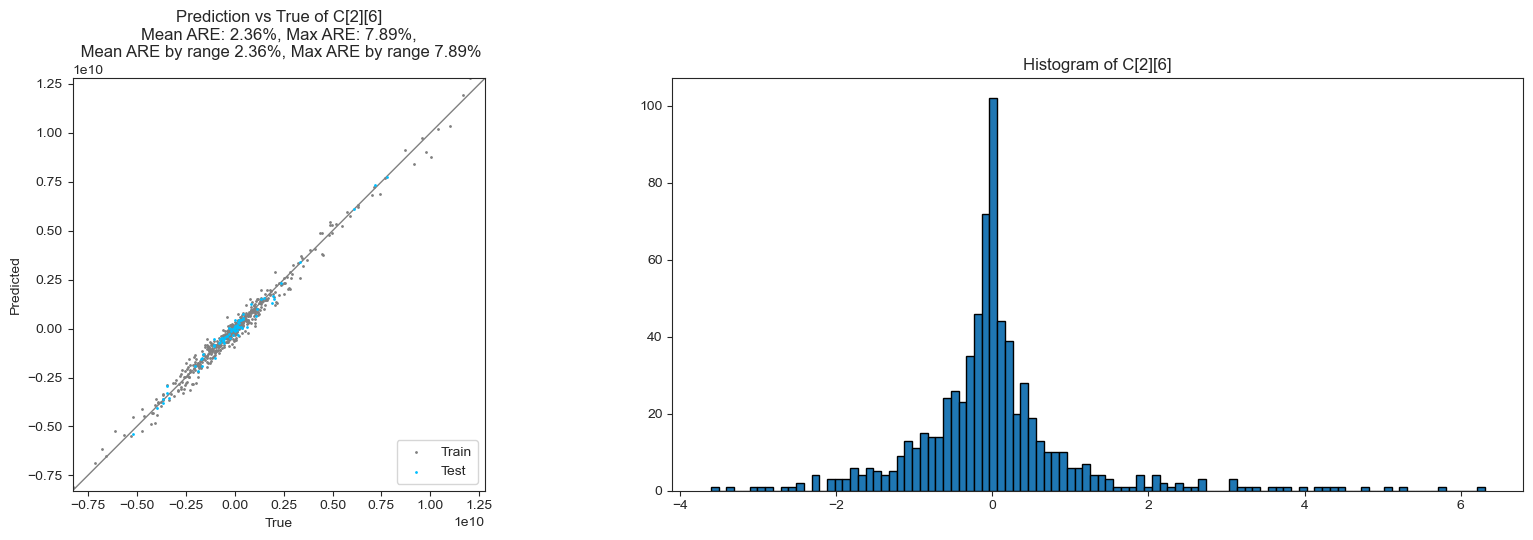

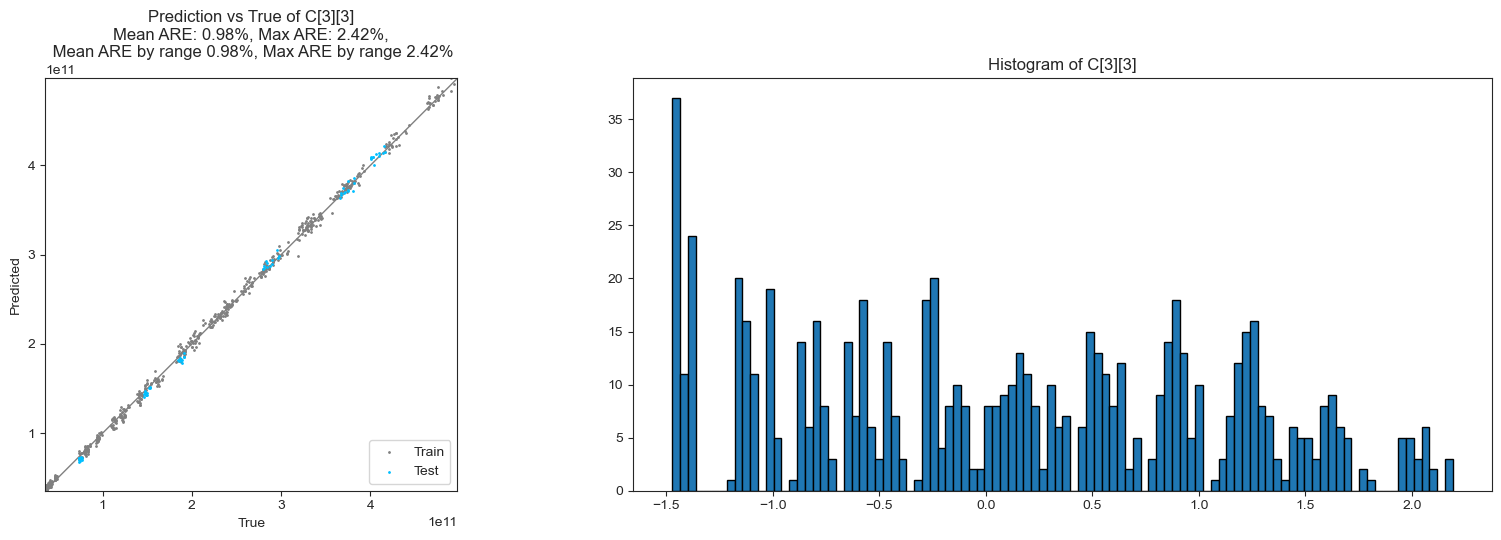

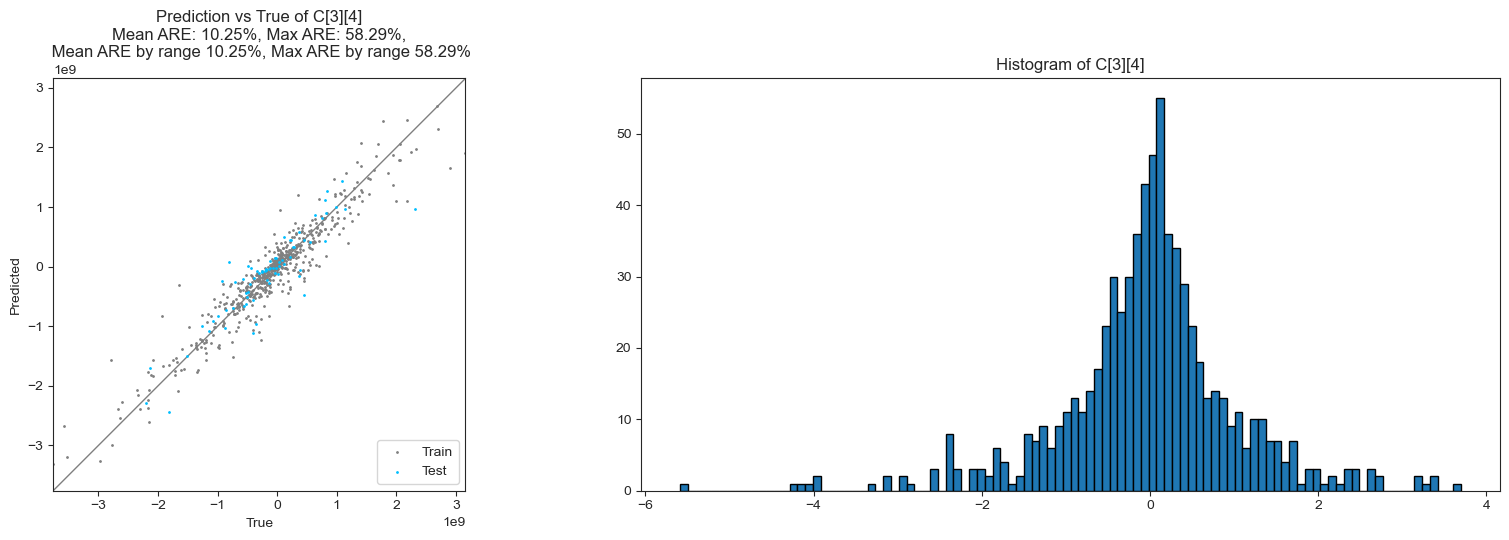

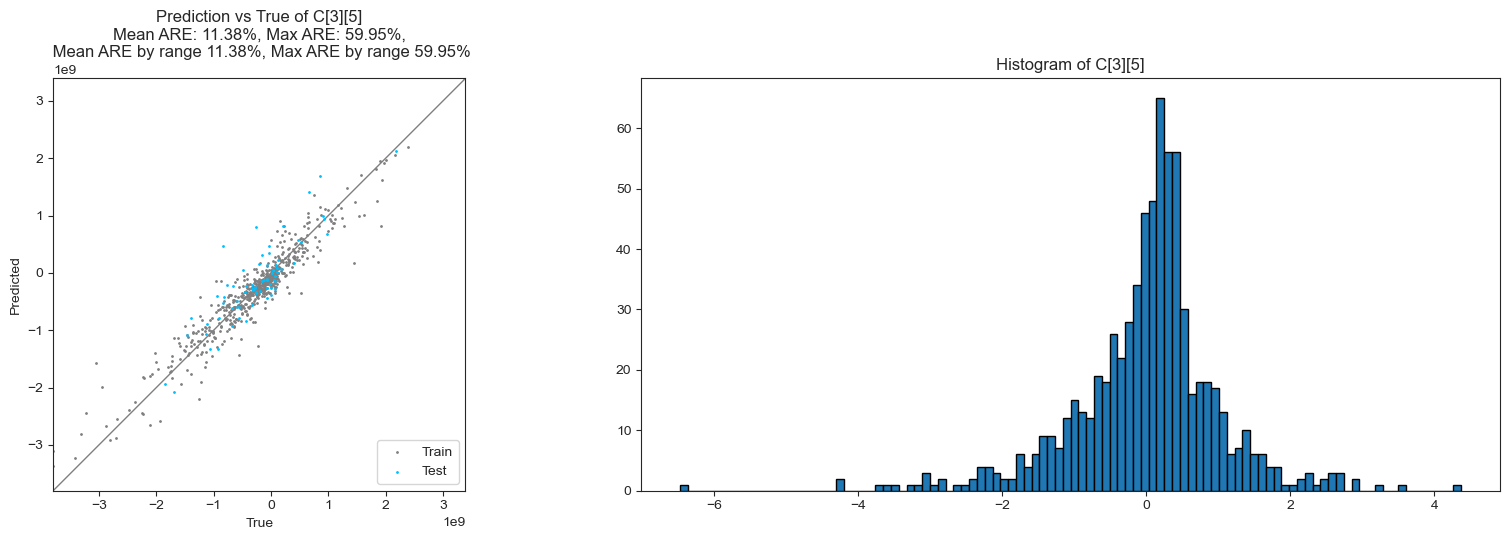

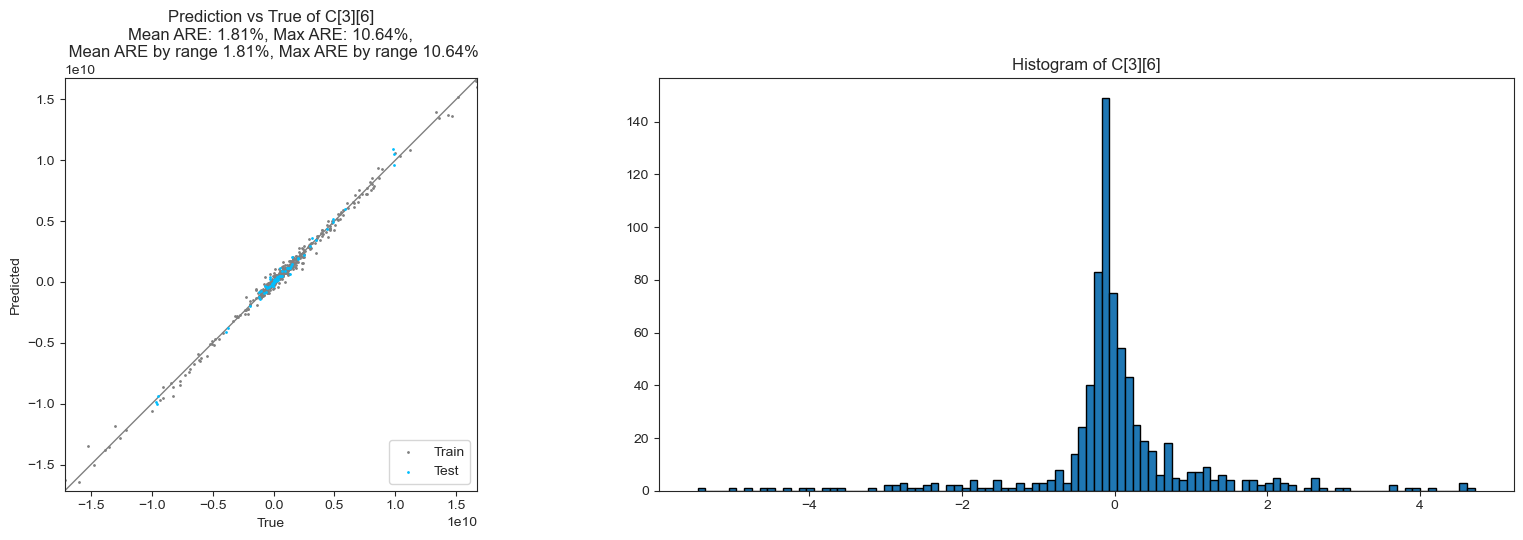

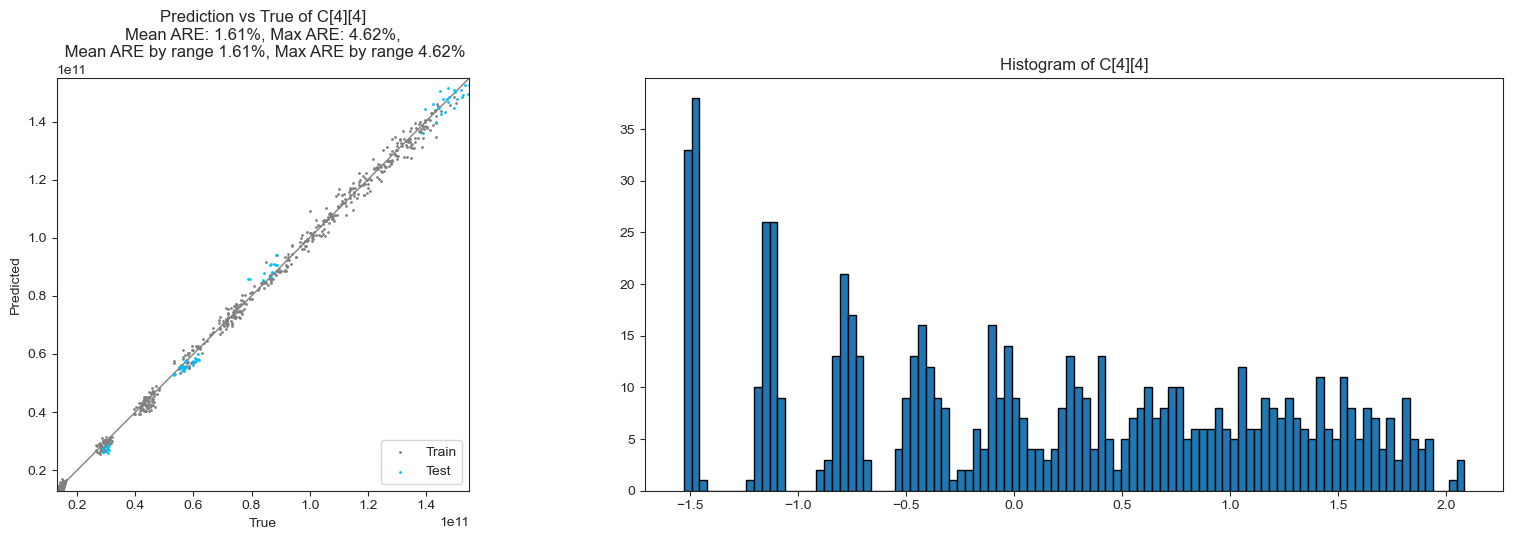

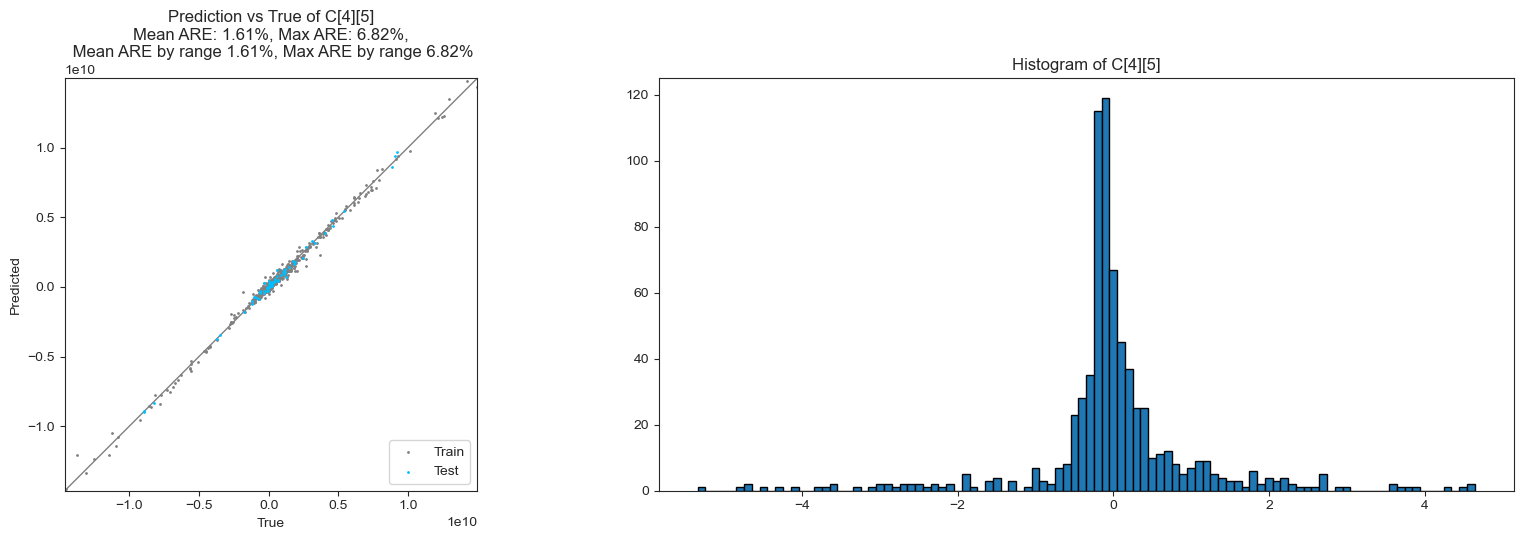

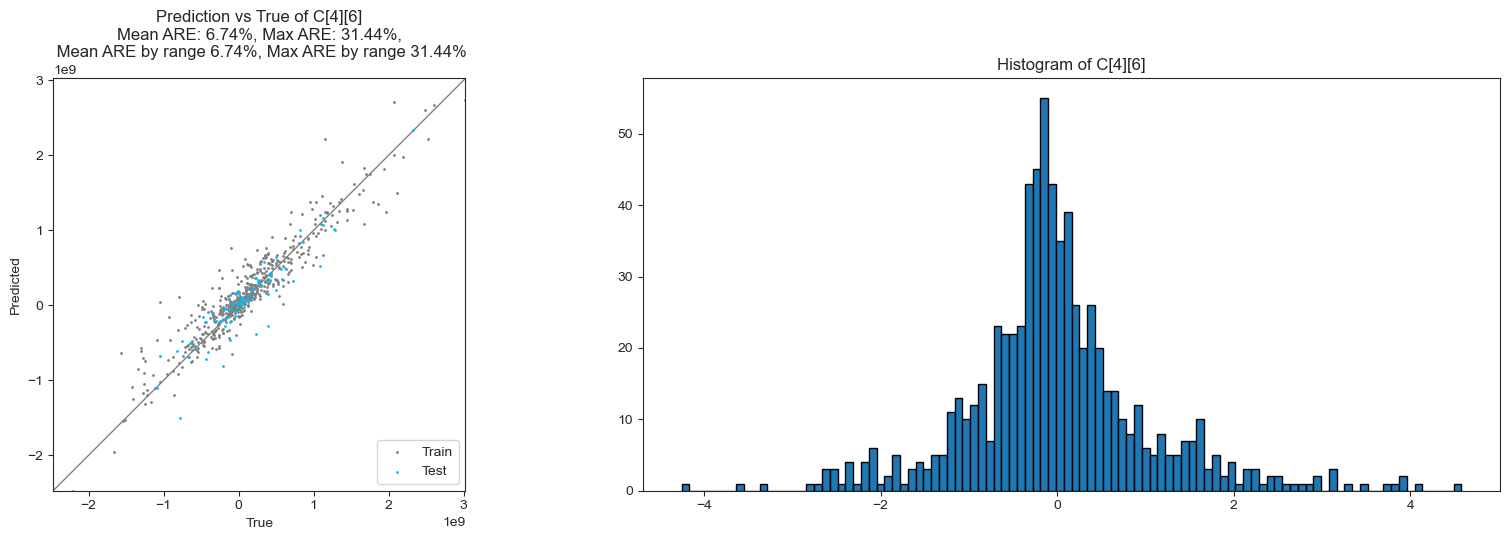

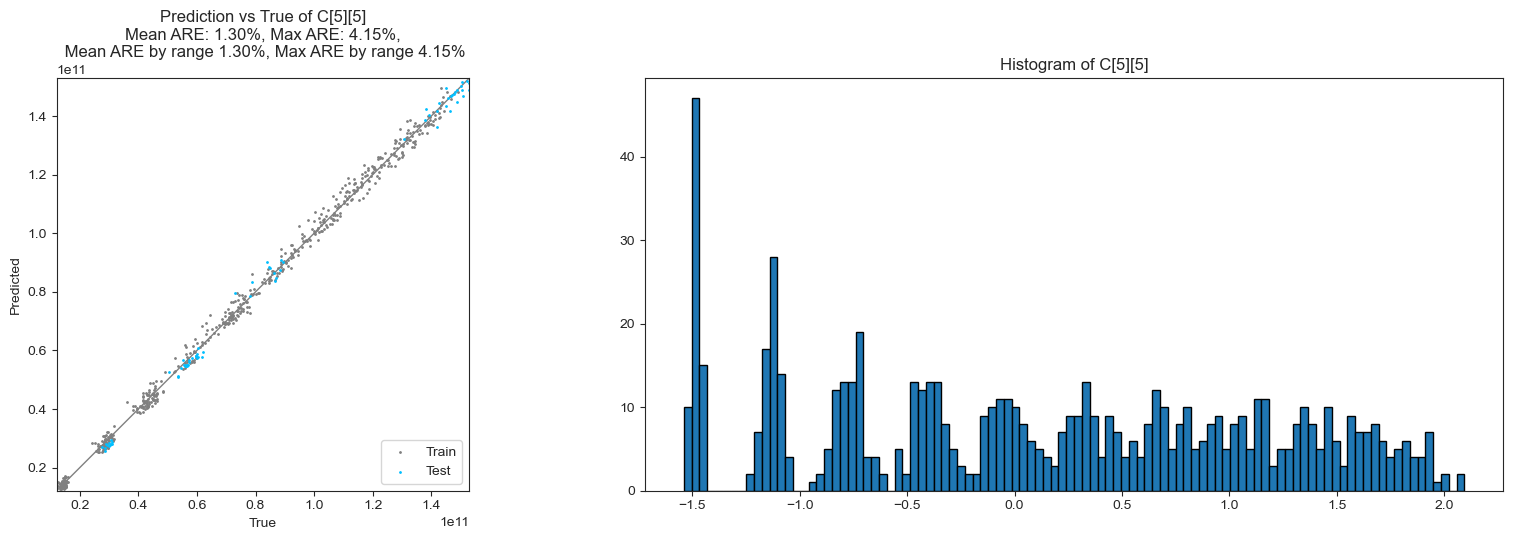

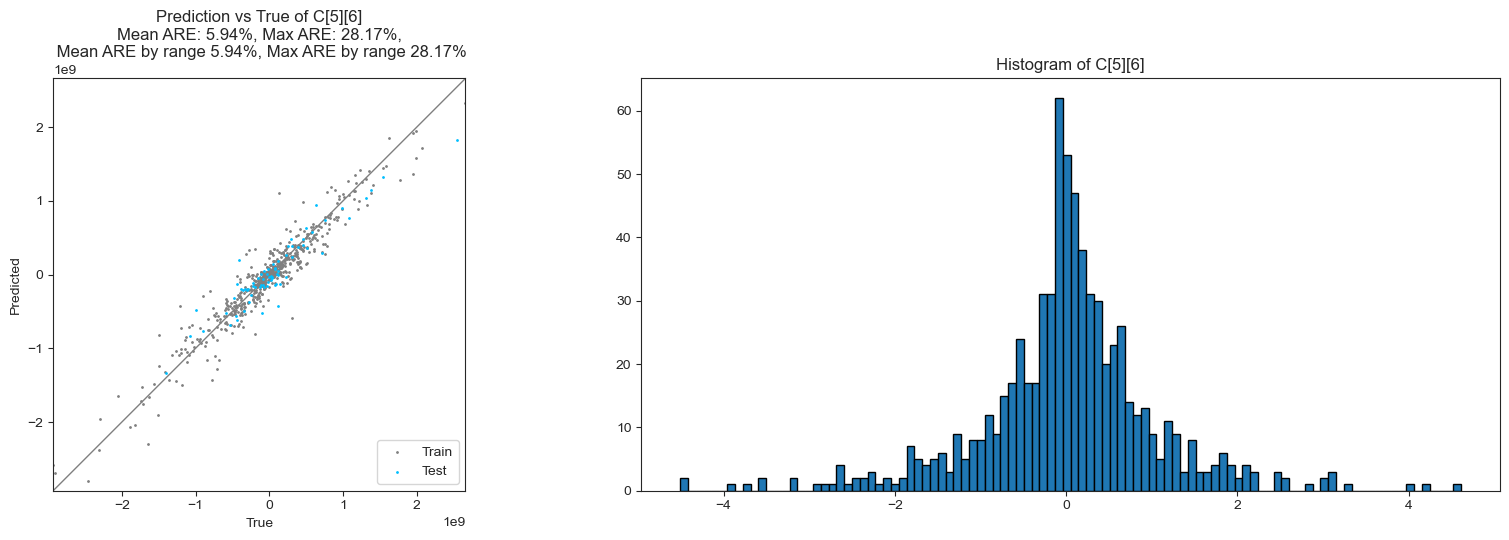

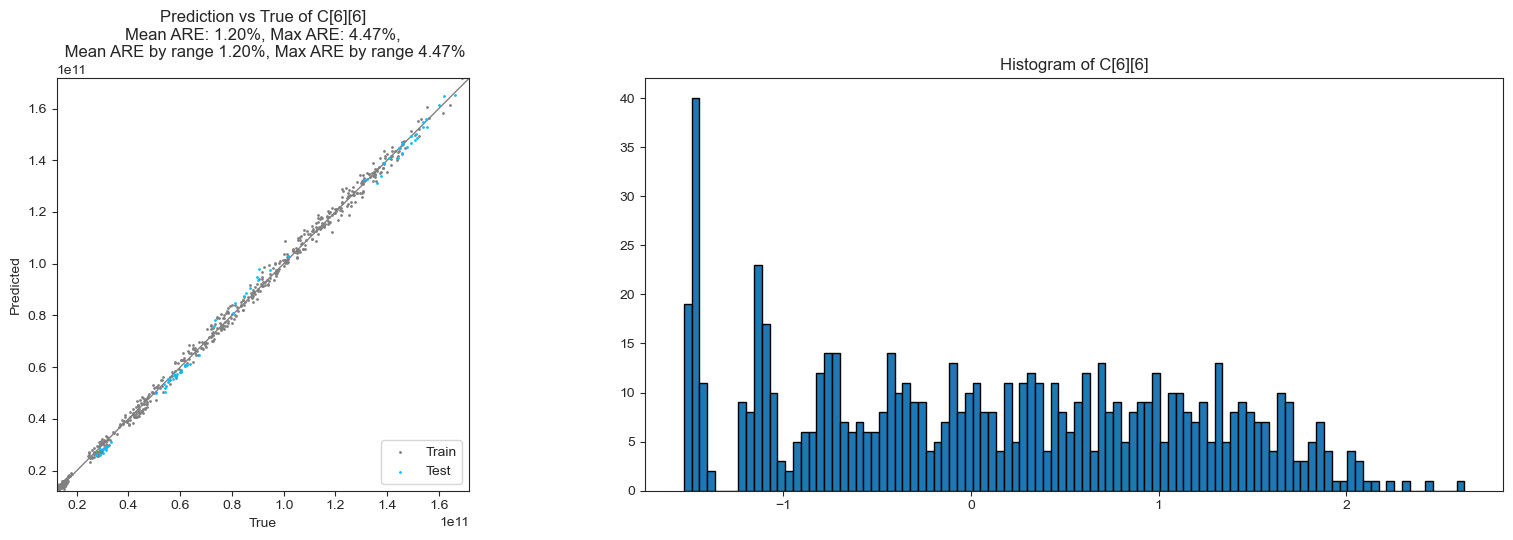

In [44]:
all_y = np.concatenate([record.y for record in data], axis=0)

for y in range(train_preds.shape[1]):
    target_name = f'C[{int(row_index[y])}][{int(col_index[y])}]'
    test_trues = valid_trues[:, y]
    test_preds = valid_preds[:, y]
    train_preds_y = train_preds[:, y]
    train_trues_y = train_trues[:, y]
    sns.set_style("ticks")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5.5), dpi=100)
    
    # Subplot 1: Prediction vs True
    max_value = max(np.max(train_trues_y), np.max(train_preds_y), np.max(test_trues), np.max(test_preds))
    min_value = min(np.min(train_trues_y), np.min(train_preds_y), np.min(test_trues), np.min(test_preds))
    ax1.plot([min_value, max_value], [min_value, max_value], 'gray', linewidth=1, zorder=1)
    ax1.scatter(train_trues_y, train_preds_y, s=1, color='gray', label='Train')
    ax1.scatter(test_trues, test_preds, color='deepskyblue', s=1, label='Test')
    
    ax1.set_xlabel('True')
    ax1.set_ylabel('Predicted')
    ax1.set_xlim([min_value, max_value])
    ax1.set_ylim([min_value, max_value])
    ax1.set_aspect(1.0/ax1.get_data_ratio(), adjustable='box')
    ax1.legend(loc="lower right", fontsize=10)
    
    # Calculate Mean and Max ARE
    ax1.set_title(f'Prediction vs True of {target_name}\nMean ARE: {meanARE[y]:.2f}%, Max ARE: {maxARE[y]:.2f}%,\n Mean ARE by range {meanARE_range[y]:.2f}%, Max ARE by range {maxARE_range[y]:.2f}%')

    # Subplot 2: Histogram
    ax2.hist(all_y[:, y], bins=100, edgecolor='black')
    ax2.set_title(f'Histogram of {target_name}')

    plt.tight_layout()
    plt.show()